Regressione LASSO
# 1. Import e caricamento Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Lasso, LassoCV


data = load_diabetes(as_frame=True)
X = data.data
y = data.target

print("Shape X:", X.shape)
print("Shape y:", y.shape)

display(X.head())
display(y.head())

Shape X: (442, 10)
Shape y: (442,)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


0    151.0
1     75.0
2    141.0
3    206.0
4    135.0
Name: target, dtype: float64

# 2. Standardizzazione

In [2]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Prime righe standardizzate:")
display(pd.DataFrame(X_scaled, columns=X.columns).head())


Prime righe standardizzate:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.800500,1.065488,1.297088,0.459841,-0.929746,-0.732065,-0.912451,-0.054499,0.418531,-0.370989
1,-0.039567,-0.938537,-1.082180,-0.553505,-0.177624,-0.402886,1.564414,-0.830301,-1.436589,-1.938479
2,1.793307,1.065488,0.934533,-0.119214,-0.958674,-0.718897,-0.680245,-0.054499,0.060156,-0.545154
3,-1.872441,-0.938537,-0.243771,-0.770650,0.256292,0.525397,-0.757647,0.721302,0.476983,-0.196823
4,0.113172,-0.938537,-0.764944,0.459841,0.082726,0.327890,0.171178,-0.054499,-0.672502,-0.980568


# 3. Baseline: regressione lineare


In [3]:
lin_reg = LinearRegression()
lin_reg.fit(X_scaled, y)

y_pred_lin = lin_reg.predict(X_scaled)

mse_lin = mean_squared_error(y, y_pred_lin)
r2_lin = r2_score(y, y_pred_lin)

print("=== Regressione Lineare ===")
print(f"MSE: {mse_lin:.4f}")
print(f"R² : {r2_lin:.4f}")


=== Regressione Lineare ===
MSE: 2859.6963
R² : 0.5177


# 4. LASSO su 100 alpha

In [4]:
alphas = np.logspace(-4, 1, 100)

mse_lasso = []
r2_lasso = []
n_nonzero = []

for a in alphas:
    lasso = Lasso(alpha=a, max_iter=10000)
    lasso.fit(X_scaled, y)
    y_pred = lasso.predict(X_scaled)

    mse_lasso.append(mean_squared_error(y, y_pred))
    r2_lasso.append(r2_score(y, y_pred))
    n_nonzero.append(np.sum(lasso.coef_ != 0))

results = pd.DataFrame({
    "alpha": alphas,
    "MSE": mse_lasso,
    "R2": r2_lasso,
    "non_zero_coef": n_nonzero
})

display(results.head())
display(results.tail())

,alpha,MSE,R2,non_zero_coef
0,0.000100,2859.696352,0.517748,10
1,0.000112,2859.696353,0.517748,10
2,0.000126,2859.696355,0.517748,10
3,0.000142,2859.696357,0.517748,10
4,0.000159,2859.696359,0.517748,10


,alpha,MSE,R2,non_zero_coef
95,6.280291,3092.095569,0.478557,4
96,7.054802,3112.199202,0.475167,4
97,7.924829,3137.556595,0.470891,4
98,8.902151,3169.553655,0.465495,4
99,10.000000,3209.929126,0.458686,4


# 5. Miglior alpha manuale

In [5]:
best_idx_man = np.argmin(mse_lasso)
best_alpha_man = alphas[best_idx_man]
best_mse_man = mse_lasso[best_idx_man]
best_r2_man = r2_lasso[best_idx_man]

print("=== Miglior alpha manuale ===")
print(f"alpha: {best_alpha_man:.6f}")
print(f"MSE  : {best_mse_man:.4f}")
print(f"R²   : {best_r2_man:.4f}")

# modello migliore manuale per ispezionare i coefficienti
best_lasso = Lasso(alpha=best_alpha_man, max_iter=10000)
best_lasso.fit(X_scaled, y)

coef_df = pd.DataFrame({
    "feature": X.columns,
    "coef": best_lasso.coef_
}).sort_values("coef", key=np.abs, ascending=False)

print("=== Coefficienti LASSO (manuale) ===")
display(coef_df)

=== Miglior alpha manuale ===
alpha: 0.000100
MSE  : 2859.6964
R²   : 0.5177
=== Coefficienti LASSO (manuale) ===


,feature,coef
4,s1,-37.663674
8,s5,35.728576
2,bmi,24.726644
5,s2,22.663639
3,bp,15.429187
1,sex,-11.406659
7,s4,8.419185
6,s3,4.798374
9,s6,3.216640
0,age,-0.475891


# 6. LassoCV

In [6]:
lasso_cv = LassoCV(alphas=alphas, cv=5, random_state=42, max_iter=10000)
lasso_cv.fit(X_scaled, y)

y_pred_cv = lasso_cv.predict(X_scaled)
mse_cv = mean_squared_error(y, y_pred_cv)
r2_cv = r2_score(y, y_pred_cv)

print("=== LassoCV ===")
print(f"alpha scelto: {lasso_cv.alpha_:.6f}")
print(f"MSE         : {mse_cv:.4f}")
print(f"R²          : {r2_cv:.4f}")

coef_cv_df = pd.DataFrame({
    "feature": X.columns,
    "coef": lasso_cv.coef_
}).sort_values("coef", key=np.abs, ascending=False)

print("=== Coefficienti LassoCV ===")
display(coef_cv_df)

=== LassoCV ===
alpha scelto: 0.075646
MSE         : 2861.6016
R²          : 0.5174
=== Coefficienti LassoCV ===


,feature,coef
8,s5,31.910281
4,s1,-27.184981
2,bmi,24.810856
3,bp,15.275831
5,s2,14.489454
1,sex,-11.235250
7,s4,6.800531
9,s6,3.182240
0,age,-0.313765
6,s3,0.000000


# 7. Grafico MSE + R²

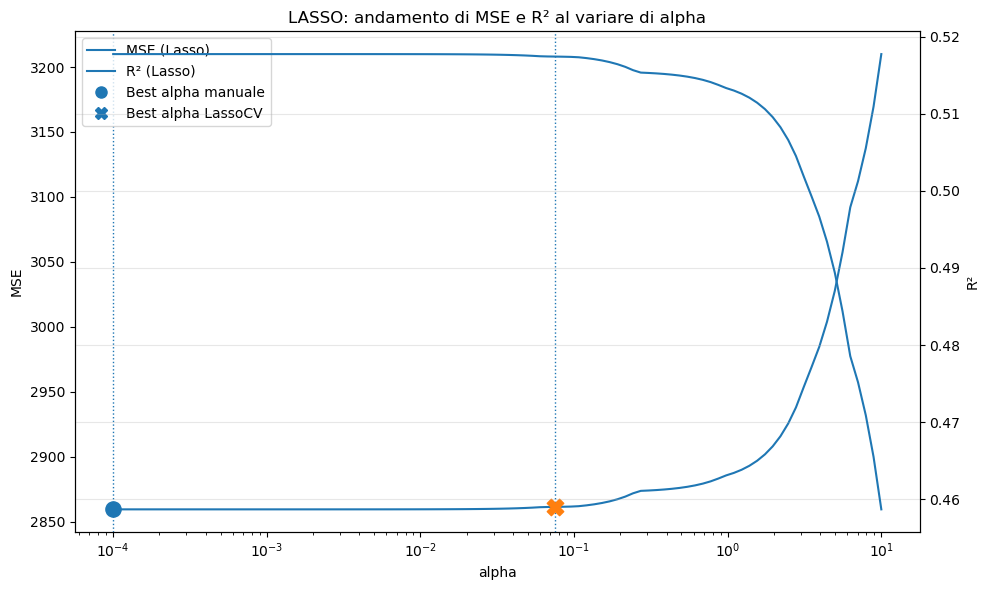

In [7]:
fig, ax1 = plt.subplots(figsize=(10, 6))

line1 = ax1.plot(alphas, mse_lasso, label="MSE (Lasso)")
ax1.set_xscale("log")
ax1.set_xlabel("alpha")
ax1.set_ylabel("MSE")
ax1.scatter(best_alpha_man, best_mse_man, s=120, zorder=5, label="Best alpha manuale")
ax1.axvline(best_alpha_man, linestyle=":", linewidth=1)

ax2 = ax1.twinx()
line2 = ax2.plot(alphas, r2_lasso, label="R² (Lasso)")
ax2.set_ylabel("R²")

ax1.scatter(lasso_cv.alpha_, mse_cv, marker="X", s=140, zorder=6, label="Best alpha LassoCV")
ax1.axvline(lasso_cv.alpha_, linestyle=":", linewidth=1)

lines = line1 + line2
labels = [l.get_label() for l in lines]

# aggiungiamo manualmente le etichette degli scatter
from matplotlib.lines import Line2D
extra_legend = [
    Line2D([0], [0], marker='o', linestyle='None', markersize=8, label='Best alpha manuale'),
    Line2D([0], [0], marker='X', linestyle='None', markersize=8, label='Best alpha LassoCV')
]

ax1.legend(handles=lines + extra_legend, loc="best")
plt.title("LASSO: andamento di MSE e R² al variare di alpha")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()